<img src="../logoutn.jpg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo de Laboratorio Nº2
#### Grupo Nº1
#### Gabriel Barale, Federico Borello, Facundo Farcy

## Consigna

- Consolidar los conceptos de los sistemas muestreados mediante el uso de ADC y DACs.
- Simular e implementar un filtro digital con el STM NUCLEO-64.
- Familiarizarse con el uso de librerías para procesamiento digital de señales.
- Medir las partes de la función transferencia H[z] para frecuencias entre 10 Hz y 10 kHz.

Se parte a partir de los diseños de filtros analógicos realizados la TS9, y se implementan versiones digitales de los mismos utilizando técnicas de diseño FIR e IIR.

<div align=center>

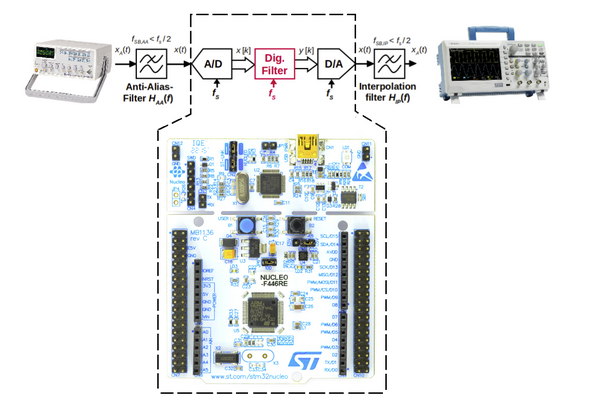

</div>

Se utiliza un STM32 NUCLEO-64 como plataforma de desarrollo, y se programa utilizando la librería CMSIS-DSP para el procesamiento digital de señales. Especificamente, se utilizan las funciones de filtrado FIR e IIR provistas por la librería:

- `arm_fir_f32`
- `arm_biquad_cascade_df1_f32`


El conexionado del sistema es el siguiente:

<div align=center>

|  #PIN  |    Descripción    |
|:------:|:-----------------:|
|   CN6 - pin6    |  GND  |
|   CN6 - pin4    |   VCC   |
|   CN8 - pin1    |  ADC_IN |
|   CN8 - pin3    |  DAC_OUT  |

</div>

A la entrada y salida se utilizan filtros analógicos pasa bajos de primer orden con frecuencia de corte en $500 [Hz]$ para evitar aliasing y suavizar la señal respectivamente.

In [3]:
# Import common packages
from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import pandas as pd
from pytc2.sistemas_lineales import plot_plantilla

## Diseño de filtros
Para el desarrollo de la práctica, se diseñaron previamente 2 filtros pasa banda con las siguientes características:
- fs1 = 0.1Hz
- fp1 = 1Hz
- fp2 = 35Hz
- fs2 = 45Hz
- ripple = 0.5dB
- atenuación = 40dB
  
Como condición, uno de ellos debía ser FIR y el otro IIR.
  

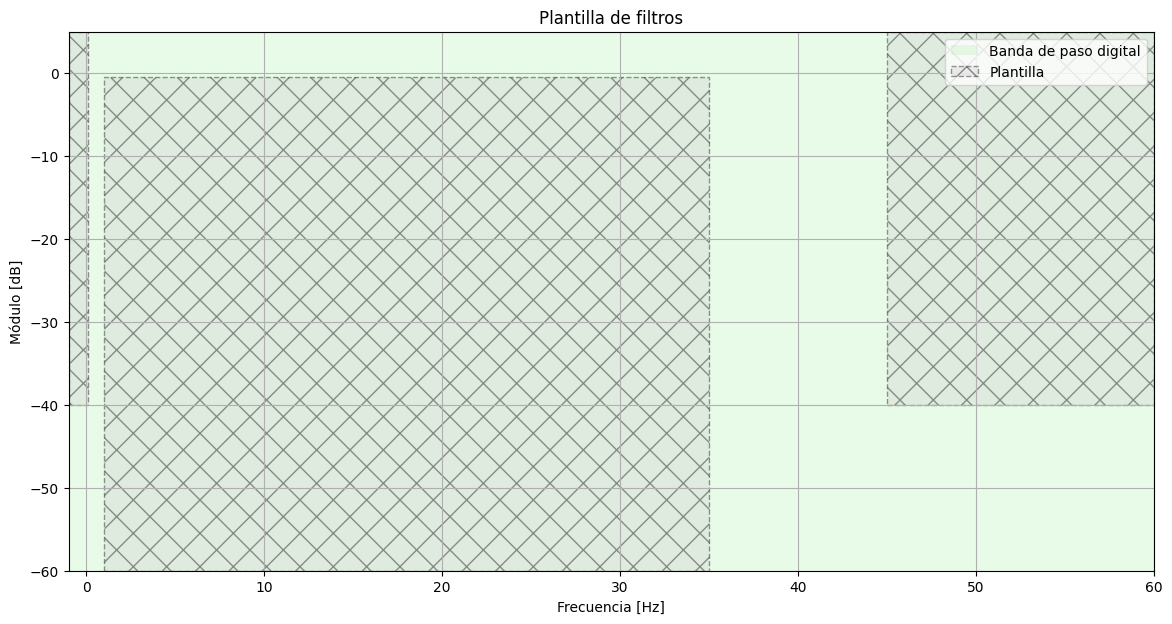

In [4]:
# filter design
ripple = 0.5 # dB
atenuacion = 40 # dB
ws1 = .1 #Hz
wp1 = 1 #Hz
wp2 = 35.0 #Hz
ws2 = 45.0 #Hz

fs = 1000 # Hz
nyq_frec = fs / 2


fig_sz_x = 14
fig_sz_y = 7
plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.axis([-1,60 , -60, 5 ]);

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
plt.title('Plantilla de filtros')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
_ = plt.legend()

### IIR

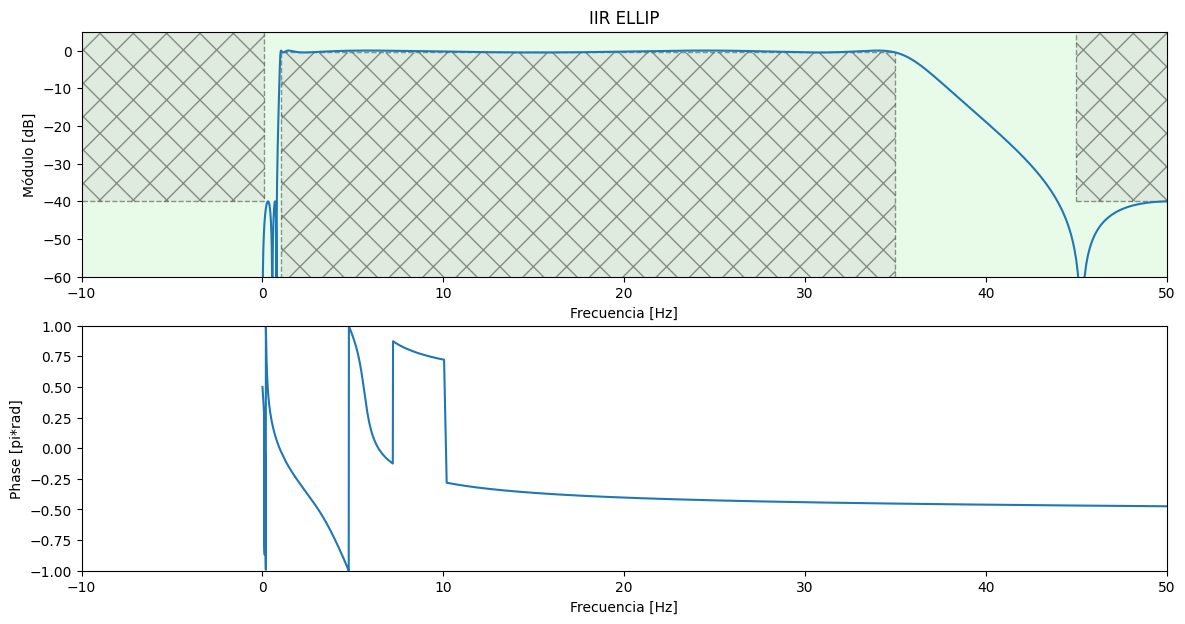

In [29]:
wp_iir = [wp1, wp2]
ws_iir = [ws1, ws2]

#Diseño el filtro iir elíptico
sos_iir_ellip = sig.iirdesign(wp= wp_iir, ws=ws_iir, gpass=ripple, gstop=atenuacion, output='sos', analog=False, ftype='ellip', fs = fs)
#Creo el eje de frecuencias
w_rad  = np.append(np.logspace(-3, 0.8, 1000), np.logspace(0.9, 1.8, 1000) )
w_rad  = np.append(w_rad, np.linspace(64, nyq_frec, 1000, endpoint=True) )

#Grafico
w_rad_ellip, h_iir_ellip= sig.freqz_sos(sos_iir_ellip, worN=w_rad, fs = fs)
fig_1 = plt.figure(1, figsize=(fig_sz_x, fig_sz_y))

fig_1.add_subplot(2,1,1)
plt.plot(w_rad, 20*np.log10(np.abs(h_iir_ellip)+1e-12), label = 'MAGN' )
plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
plt.axis([-10, 50, -60, 5]);
plt.title('IIR ELLIP')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')

fig_1.add_subplot(2,1,2)
plt.plot(w_rad/(2*np.pi), np.unwrap(np.angle(h_iir_ellip)/np.pi), label = 'PHASE' )
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Phase [pi*rad]')
plt.axis([-10, 50, -1, 1]);

### FIR

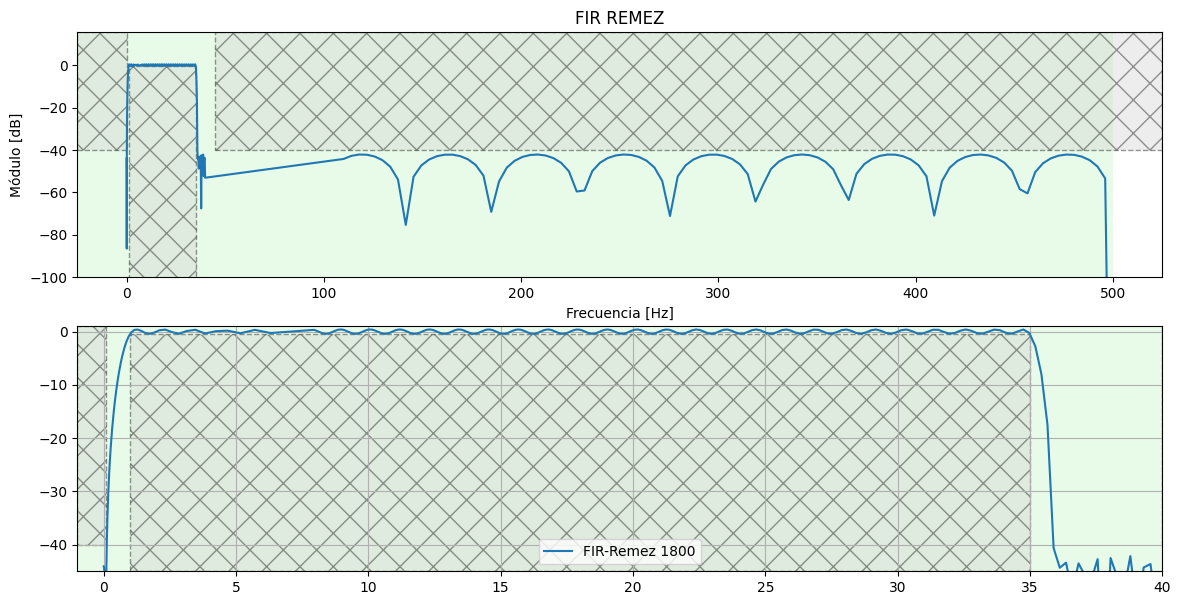

In [39]:
cant_coeficientes = 1800
num_remez = sig.remez(cant_coeficientes, bands=[0.0,ws1 ,wp1,wp2,wp2+wp1-ws1 , nyq_frec],desired=[0,1,0], weight=[15,2,12], fs=fs)
den = 1.0
# muestreo el filtro donde me interesa verlo según la plantilla.
w  = np.append(np.logspace(-10, 0.8, 250), np.logspace(0.9, 1.6, 250) )
w  = np.append(w, np.linspace(110, nyq_frec, 100, endpoint=True) )

_, hh_remez= sig.freqz(num_remez, den, w, fs = fs)

fig_=plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
fig_.add_subplot(2,1,1)
plt.plot(w, 20 * np.log10(abs(hh_remez)), label='FIR-Remez {:d}'.format(num_remez.shape[0]))
plt.title('FIR REMEZ')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
fig_.add_subplot(2,1,2)
plt.plot(w, 20 * np.log10(abs(hh_remez)), label='FIR-Remez {:d}'.format(num_remez.shape[0]))
plt.axis([-1, 40, -45, 1 ])
plt.grid()

axes_hdl = plt.gca()
axes_hdl.legend()
plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
plt.show()

## Laboratorio

Para la realización de la práctica, se utilizó:
- Fuente de alimentación:  Vo= $3.3[V]$
- Generador de señales Vpp=$1.5[V]$ , Voffset = $1.5[V]$
- Osciloscopio

### Parte1: Caracterización de filtros digitales con osciloscopio
Para obtener la respuesta en frecuencia de los filtros, se realizó un barrido en frecuencia con una señal senoidal. Se tomó nota de los valores para distintas frecuencias y se obtuvo lo siguiente:

IIR- Ellip,Unnamed: 1,Unnamed: 2,FIR,Unnamed: 4,Unnamed: 5
VinPP,Frec,VoPP,VinPP,Frec,VoPP
3.07,15,0.1,3.07,20.4,0.4
3.07,17,0.12,3.07,20.78,1.74
3.07,19,0.15,3.07,20.9,2.18
3.07,20.2,0.28,3.07,21,2.74
3.07,21.15,0.64,3.07,21.1,2.9
3.07,22.5,1.5,3.07,21.2,3.09
3.07,23.6,1.91,3.07,21.41,3.14
3.07,28.1,2.4,3.07,30.5,3.11
3.07,29.2,2.44,3.07,34.1,2.77


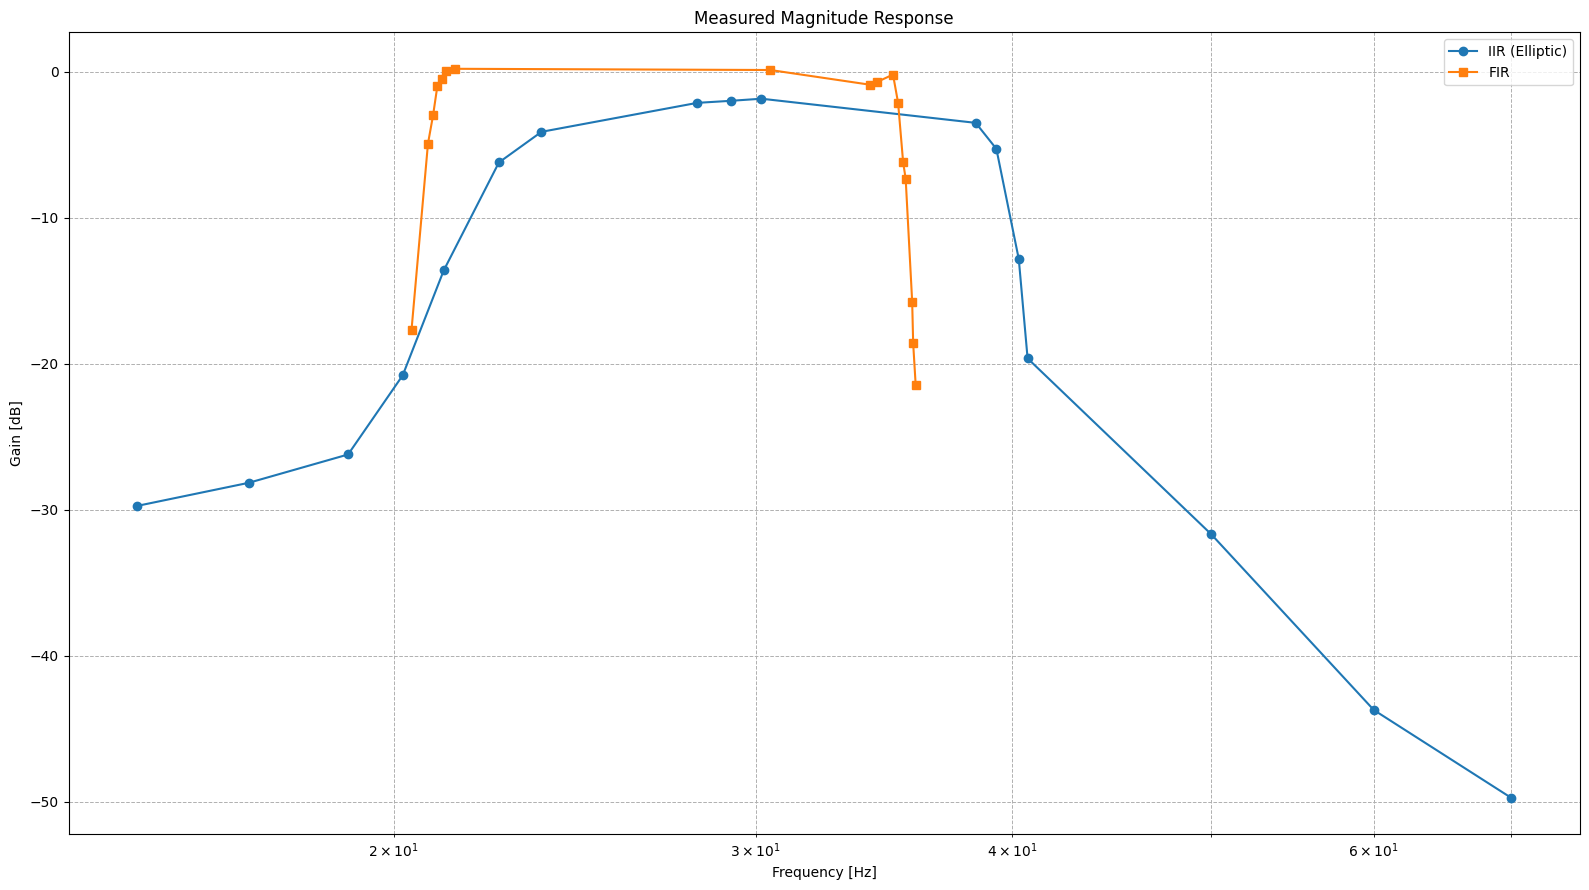

In [40]:
# === Read CSV ===
df = pd.read_csv("TPL2_meas.csv")

# === HTML Table ===
table_html = df.to_html(classes="my-table", border=1, index=False)

html_code = f"""
<button onclick="var tbl = document.getElementById('myTable'); 
                 if(tbl.style.display === 'none') {{
                     tbl.style.display = 'table';
                 }} else {{
                     tbl.style.display = 'none';
                 }}">
  Show/Hide Table
</button>

<div id="myTable" style="display:none;">
  {table_html}
</div>
"""

display(HTML(html_code))

# === Compute magnitude responses ===
# Columns: VinPP,Frec,VoPP,VinPP,Frec,VoPP
vin_iir = df.iloc[1:, 0].astype(float)
freq_iir = df.iloc[1:, 1].astype(float)
vout_iir = df.iloc[1:, 2].astype(float)

vin_fir = df.iloc[1:, 3].astype(float)
freq_fir = df.iloc[1:, 4].astype(float)
vout_fir = df.iloc[1:, 5].astype(float)

gain_iir = 20 * np.log10(vout_iir / vin_iir)
gain_fir = 20 * np.log10(vout_fir / vin_fir)

# === Plot ===
plt.figure(figsize=(16, 9))
plt.semilogx(freq_iir, gain_iir, "o-", label="IIR (Elliptic)")
plt.semilogx(freq_fir, gain_fir, "s-", label="FIR")

plt.title("Measured Magnitude Response")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Gain [dB]")
plt.grid(True, which="both", linestyle="--", linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()

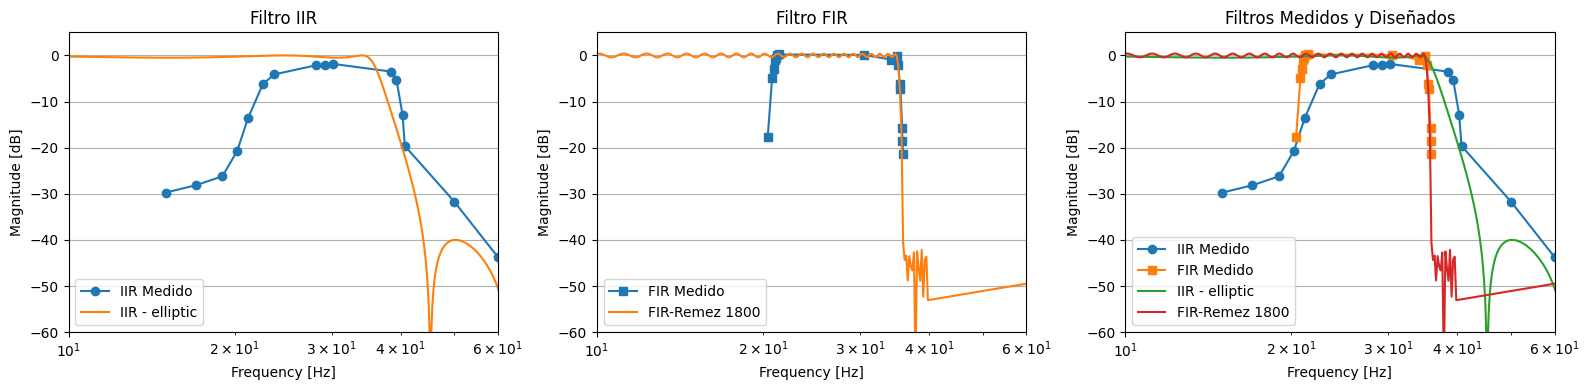

In [41]:
# Plot Junto a los Filtros medidos
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(16, 4))

ax1.semilogx(freq_iir, gain_iir, "o-", label="IIR Medido")
ax1.plot(w_rad_ellip, 20 * np.log10(np.abs(h_iir_ellip) + 1e-12), label="IIR - elliptic")
ax1.set_title("Filtro IIR")
ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel("Magnitude [dB]")
ax1.legend()
ax1.grid()
ax1.axis([10, 60, -60, 5])

ax2.semilogx(freq_fir, gain_fir, "s-", label="FIR Medido")
ax2.plot(w, 20 * np.log10(np.abs(hh_remez)), label='FIR-Remez {:d}'.format(num_remez.shape[0]))
ax2.set_title("Filtro FIR")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Magnitude [dB]")
ax2.legend()
ax2.grid()
ax2.axis([10, 60, -60, 5])

ax3.semilogx(freq_iir, gain_iir, "o-", label="IIR Medido")
ax3.semilogx(freq_fir, gain_fir, "s-", label="FIR Medido")
ax3.plot(w_rad_ellip, 20 * np.log10(np.abs(h_iir_ellip) + 1e-12), label="IIR - elliptic")
ax3.plot(w, 20 * np.log10(np.abs(hh_remez)), label='FIR-Remez {:d}'.format(num_remez.shape[0]))
ax3.set_title("Filtros Medidos y Diseñados")
ax3.set_xlabel("Frequency [Hz]")
ax3.set_ylabel("Magnitude [dB]")
ax3.legend()
ax3.grid()
ax3.axis([10, 60, -60, 5])

plt.tight_layout()
plt.show()

#### Comentarios de los Resultados Obtenidos

Se observa una buena concordancia entre los resultados simulados y experimentales, no obstante, hay una atenuación en la zona de paso del filtro IIR que no se había previsto en la simulación. No se pudo determinar la causa de esta atenuación, ya que con el filtro FIR no se observó este comportamiento.
### Parte 2: Caracterización con analizador de audio
El siguiente objetivo de la práctica fue comparar la respuesta obtenida con el osciloscopio, con la obtenida con un analizador de audio. Sin embargo, por problemas relacionados a la respuesta del analizador a frecuencias bajas, se tuvo que modificar el filtro, de la siguiente manera:
- fs1:100Hz
- fp1:105Hz
- fp2:135Hz
- fs2:140Hz
#### Rediseño IIR y FIR

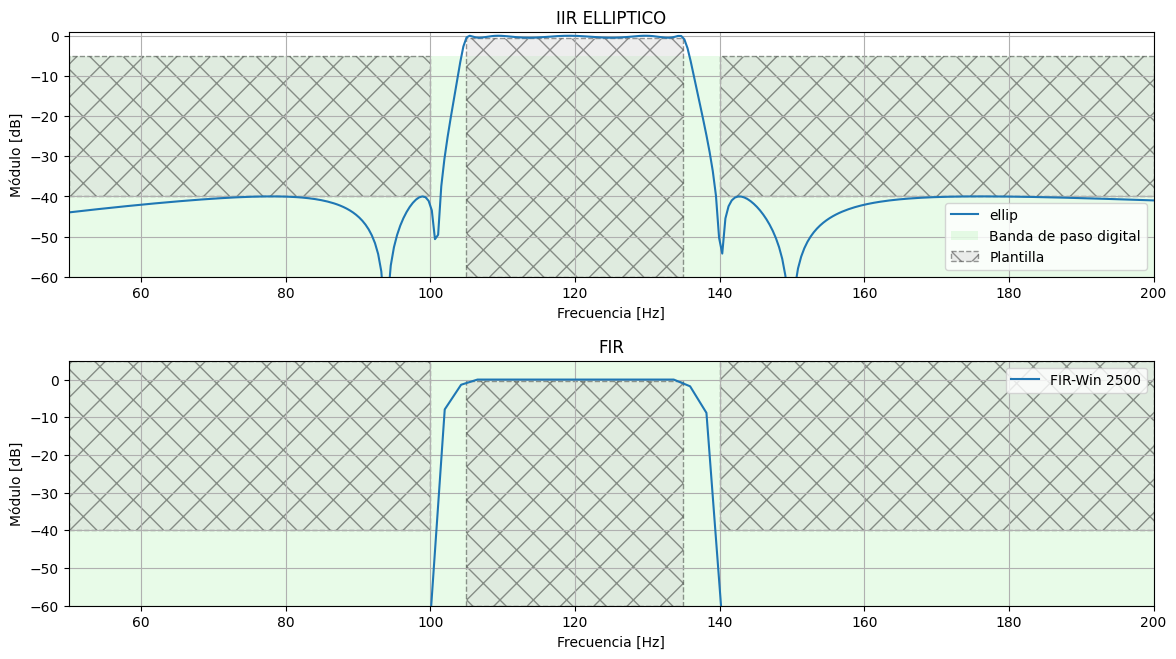

In [44]:
ws1 = 100.0 #Hz
wp1 = 105.0 #Hz
wp2 = 135.0#Hz
ws2 = 140.0 #Hz

#IIR
wp_iir = [wp1, wp2]
ws_iir = [ws1, ws2]
sos_iir_ellip = sig.iirdesign(wp= wp_iir, ws=ws_iir, gpass=ripple, gstop=atenuacion, output='sos', analog=False, ftype='ellip', fs = fs)
w_rad  = np.append(np.logspace(-3, 0.8, 1000), np.logspace(0.9, 1.8, 1000) )
w_rad  = np.append(w_rad, np.linspace(64, nyq_frec, 1000, endpoint=True) )
w_rad_ellip, h_iir_ellip = sig.freqz_sos(sos_iir_ellip, worN=w_rad, fs = fs)

#FIR
cant_coeficientes = 2500
num_win = sig.firwin2(cant_coeficientes, freq = (0, ws1, wp1, wp2, ws2, nyq_frec), gain = (0, 0, 1, 1, 0, 0) , window=('kaiser',2), fs = fs )
den = 1.0
w  = np.append(np.logspace(-1, 0.8, 250), np.logspace(0.9, 1.6, 250) )
w  = np.append(w, np.linspace(50, nyq_frec, 200, endpoint=True) )
_, hh_win = sig.freqz(num_win, den, w, fs = fs)

# GRAFICOS
fig_1 = plt.figure(1, figsize=(fig_sz_x, fig_sz_y))

ax1 = fig_1.add_subplot(2,1,1)
ax1.plot(w_rad, 20*np.log10(np.abs(h_iir_ellip)+1e-12), label='ellip')
ax1.set_title('IIR ELLIPTICO')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('Módulo [dB]')
ax1.grid()
ax1.axis([50, 200, -60, -5])
plot_plantilla(filter_type='bandpass', fpass=(wp1, wp2), fstop=(ws1, ws2),ripple=ripple, attenuation=atenuacion, fs=fs)
ax1.legend()

ax2 = fig_1.add_subplot(2,1,2)
ax2.plot(w, 20*np.log10(abs(hh_win)), label='FIR-Win {:d}'.format(num_win.shape[0]))
ax2.set_title('FIR')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Módulo [dB]')
ax2.grid()
ax2.axis([50, 200, -60, 5])
ax2.legend()
plot_plantilla(filter_type='bandpass', fpass=(wp1, wp2), fstop=(ws1, ws2),ripple=ripple, attenuation=atenuacion, fs=fs)
pos2 = ax2.get_position()
ax2.set_position([pos2.x0, pos2.y0 - 0.05, pos2.width, pos2.height])  # desfase hacia abajo



#### Medición

Con un analizador de audio se midió dicho filtro modificado, obteniendo lo siguiente:

##### Filtro FIR
<img src="FIR.jpeg">

##### Filtro IIR
<img src="IIR.jpeg">

#### Comentarios
Si bien la respuesta en frecuencia dio desfasada respecto a lo diseñado, la forma se mantuvo bastante similar a lo esperado. Se desconocen los motivos del corrimiento en frecuencia, aunque se asume pueda deberse a algún problema de configuración 

# Conclusiones y Comentarios Finales

Tras diseñar y simular con éxito el filtro digital a partir de una plantilla, se llevó a la práctica el circuito utilizando un microcontrolador STM32 NUCLEO-64. Se implementaron tanto el filtro FIR como el IIR utilizando la librería CMSIS-DSP, lo que facilitó el proceso de desarrollo.

Para verificar el correcto funcionamiento del filtro, se empleó un generador de señales de frecuencia variable junto con un osciloscopio, permitiendo realizar un barrido en frecuencia. De esta forma, se obtuvo la magnitud de la señal, datos que fueron transferidos al notebook para elaborar los gráficos correspondientes.

Finalmente, se utilizó un analizador de audio que realiza el barrido en frecuencia de forma automática, proporcionando directamente los gráficos.

Las mediciones obtenidas mediante el osciloscopio y el analizador de audio concuerdan con los resultados de las simulaciones realizadas previamente en cuanto al ancho de la banda de paso, lo que confirma la validez del diseño y el correcto desempeño del filtro en la práctica. Hay una discrepancia en la frecuencia central entre ambos métodos de medición, pero no se pudo determinar la causa de este corrimiento. Y además, se observó una atenuación en la zona de paso del filtro IIR que no se había previsto en la simulación, cuya causa tampoco se pudo determinar.